This example demonstrates how to simulate steady channel flow in **20 lines of code!** We recommend using a Python notebook (`.ipynb`) for an interactive experience.

### 1. Define the Geometry and Physics

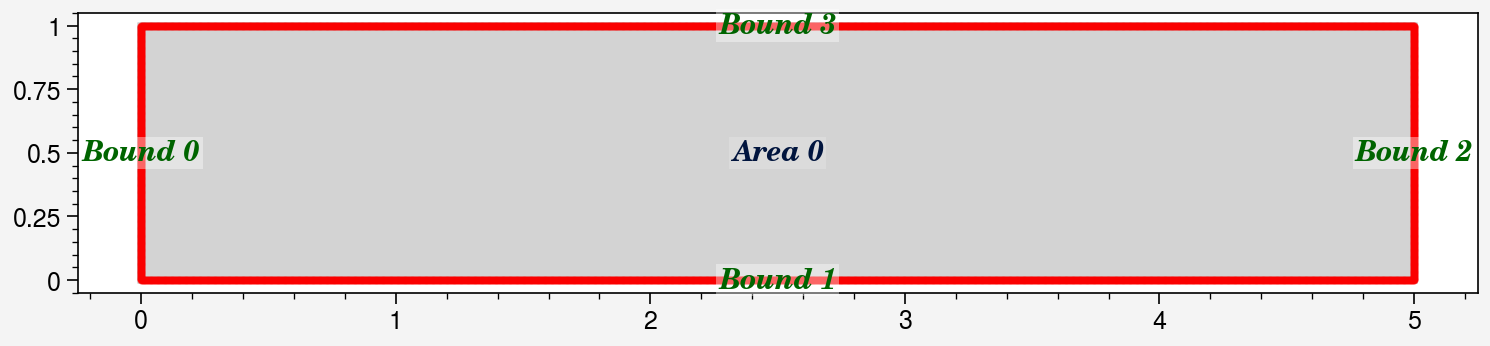

In [1]:
import deepflow as df
df.manual_seed(69)

# Create a 5x1 rectangle
rectangle = df.geometry.rectangle([0, 5], [0, 1])
domain = df.domain(rectangle)
domain.show_setup()

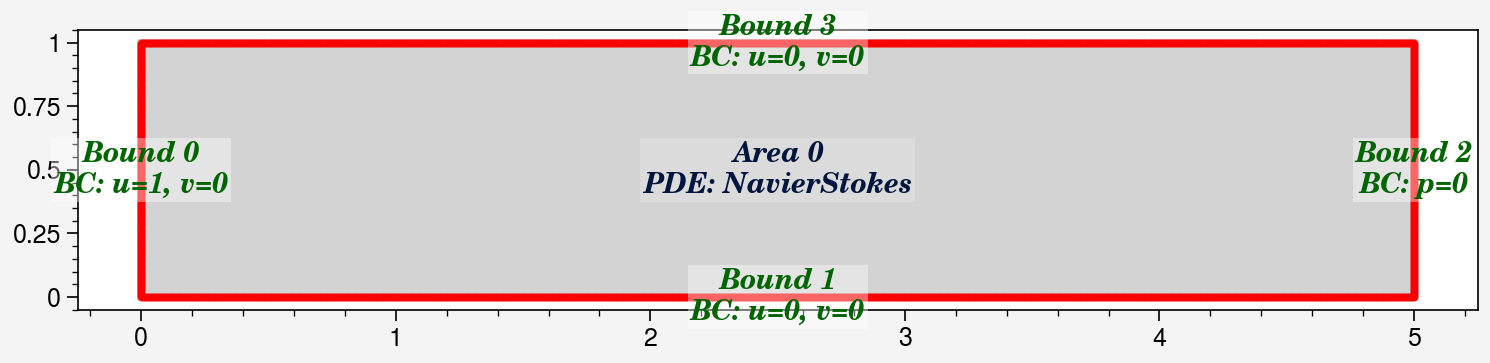

In [2]:
# Define Boundary Conditions
domain.bound_list[0].define_bc({'u': 1, 'v': 0})   # Inflow: u=1
domain.bound_list[1].define_bc({'u': 0, 'v': 0})  # Wall: No slip
domain.bound_list[2].define_bc({'p': 0})          # Outflow: p=0
domain.bound_list[3].define_bc({'u': 0, 'v': 0})  # Wall: No slip

# Define PDE (Navier-Stokes)
domain.area_list[0].define_pde(df.pde.NavierStokes(U=0.0001, L=1, mu=0.001, rho=1000))
domain.show_setup()

### 2. Generate Training Data

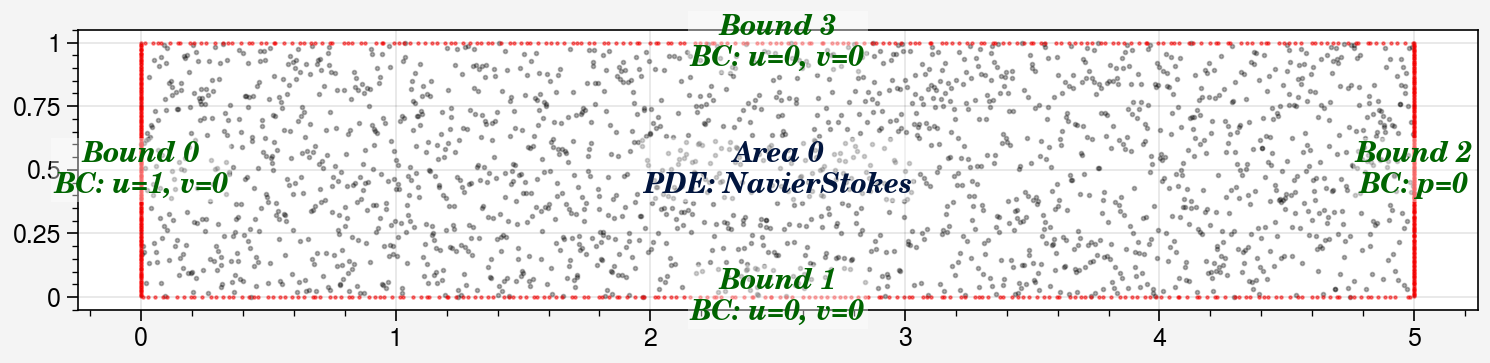

In [3]:
# Sample points: [Left, Bottom, Right, Top], [Interior]
domain.sampling_lhs([200, 200, 200, 200], [2000])
domain.show_coordinates(display_physics=True)

In [4]:
def do_r3(epoch, model):
    if epoch>0:
        domain.sampling_R3_([], [2000])
        if epoch % 1000 == 0:
            domain.show_coordinates(display_resampling=True)
            print(domain)

def do_random(epoch, model):
    if epoch%50 == 0:
        domain.sampling_lhs([200, 200, 200, 200], [2000])

### 3. Create and Train the Model

In [5]:
model0 = df.PINN(width=32, length=4)
model1, model1_best = model0.train_adam(
    calc_loss = df.calc_loss_weighted(domain, bc_weights=1, pde_weights=1),
    learning_rate=0.004,
    epochs=10000,
    do_between_epochs=do_random,
    use_scheduler=True)

Epoch: 1, total_loss: 1.66237, bc_loss: 1.65772, pde_loss: 0.00465
Epoch: 200, total_loss: 0.09694, bc_loss: 0.08372, pde_loss: 0.01322
Epoch: 400, total_loss: 0.03418, bc_loss: 0.02823, pde_loss: 0.00595
Epoch: 600, total_loss: 0.02244, bc_loss: 0.01981, pde_loss: 0.00263
Epoch: 800, total_loss: 0.02114, bc_loss: 0.01849, pde_loss: 0.00265
Epoch: 1000, total_loss: 0.01656, bc_loss: 0.01482, pde_loss: 0.00174
Epoch: 1200, total_loss: 0.01475, bc_loss: 0.01292, pde_loss: 0.00183
Epoch: 1400, total_loss: 0.01410, bc_loss: 0.01200, pde_loss: 0.00210
Epoch: 1600, total_loss: 0.01119, bc_loss: 0.00972, pde_loss: 0.00148
Epoch: 1800, total_loss: 0.01065, bc_loss: 0.00917, pde_loss: 0.00148
Epoch: 2000, total_loss: 0.01009, bc_loss: 0.00874, pde_loss: 0.00134
Epoch: 2200, total_loss: 0.01290, bc_loss: 0.01153, pde_loss: 0.00137
Epoch: 2400, total_loss: 0.00818, bc_loss: 0.00700, pde_loss: 0.00119
Epoch: 2600, total_loss: 0.00925, bc_loss: 0.00810, pde_loss: 0.00115
Epoch: 2800, total_loss: 0.

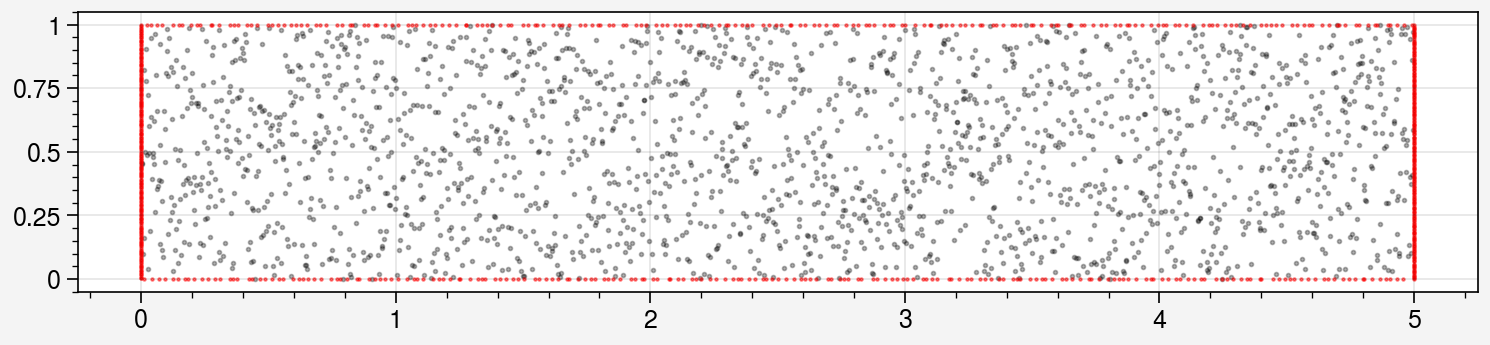

In [6]:
domain.show_coordinates()

### 4. Visualize Results

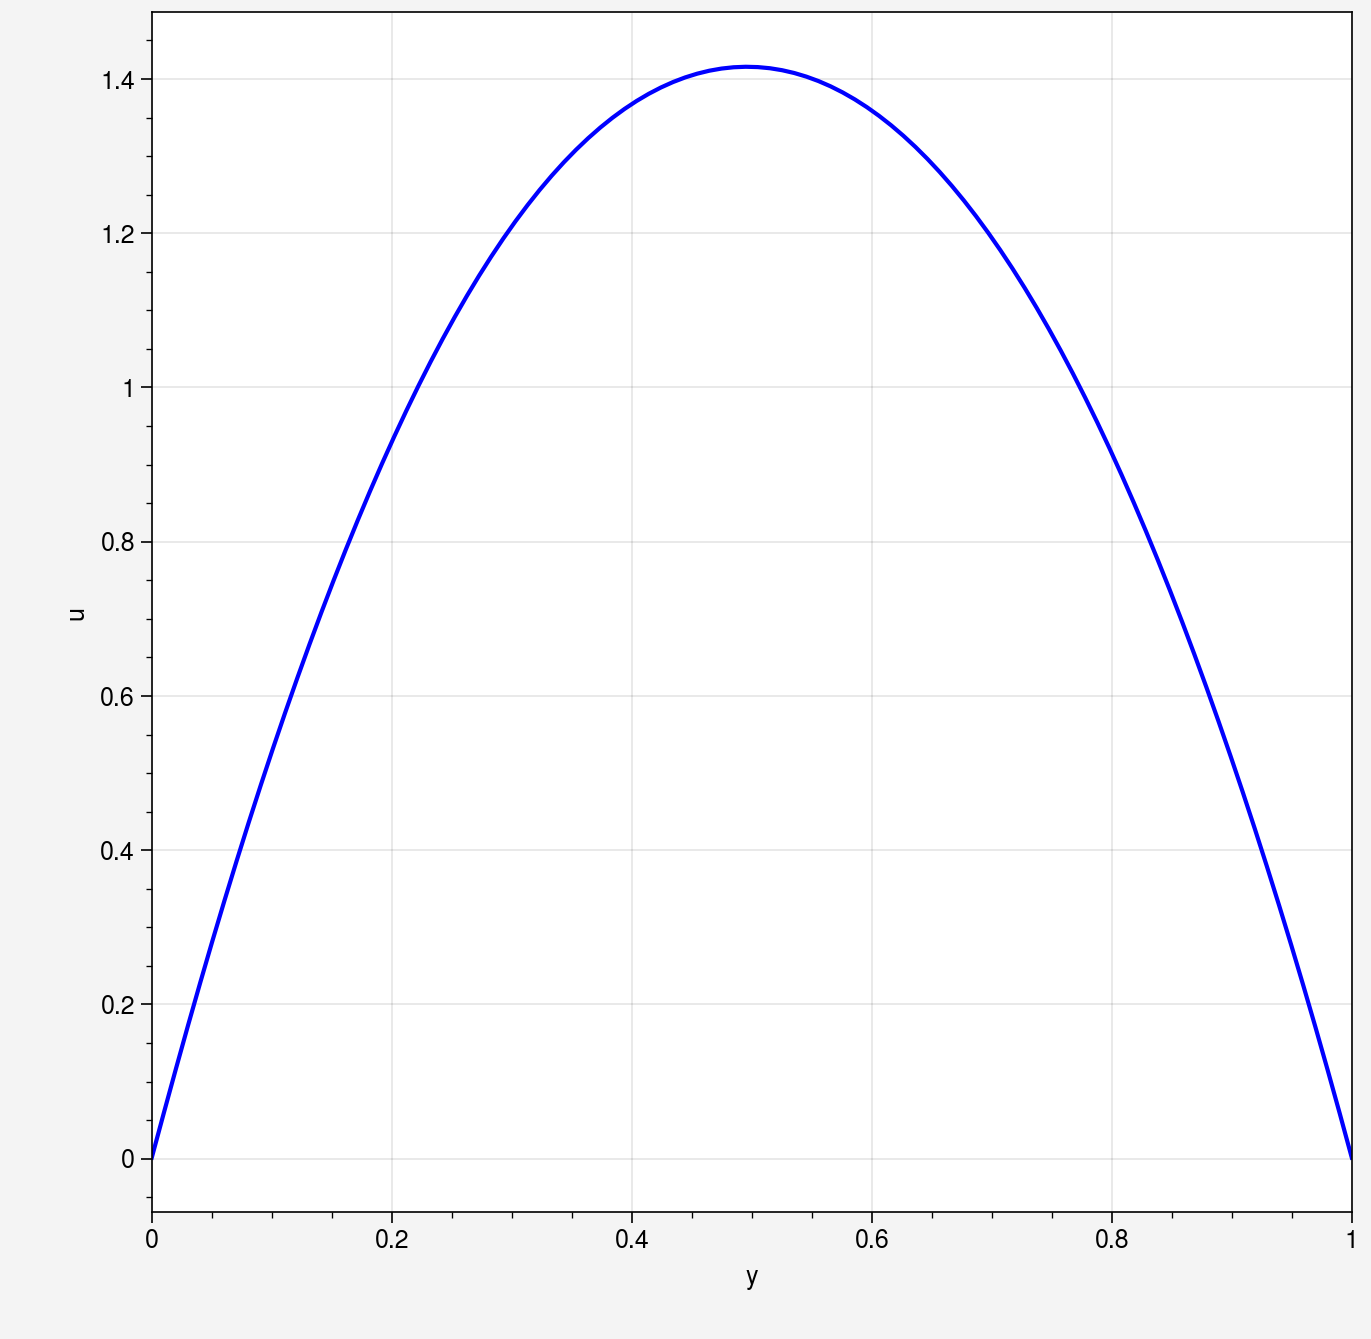

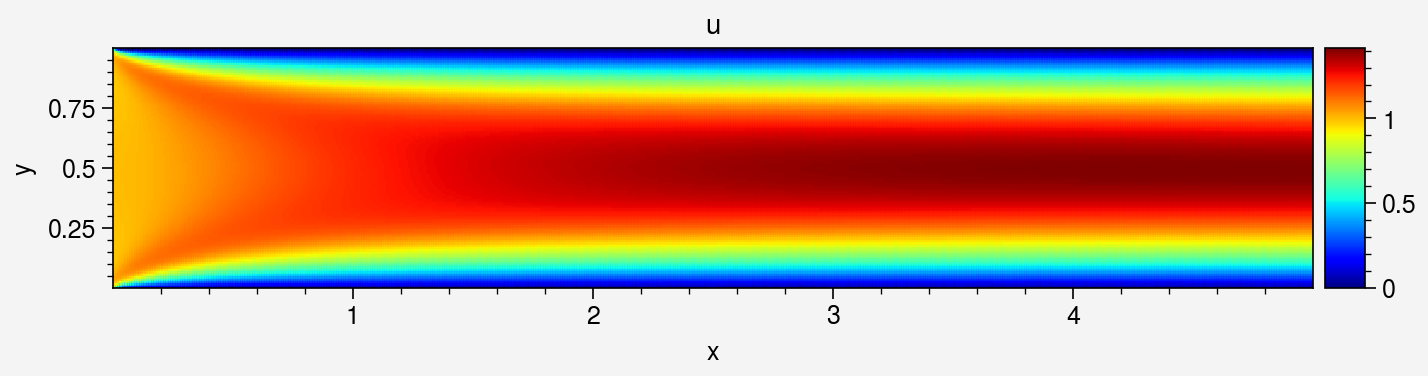

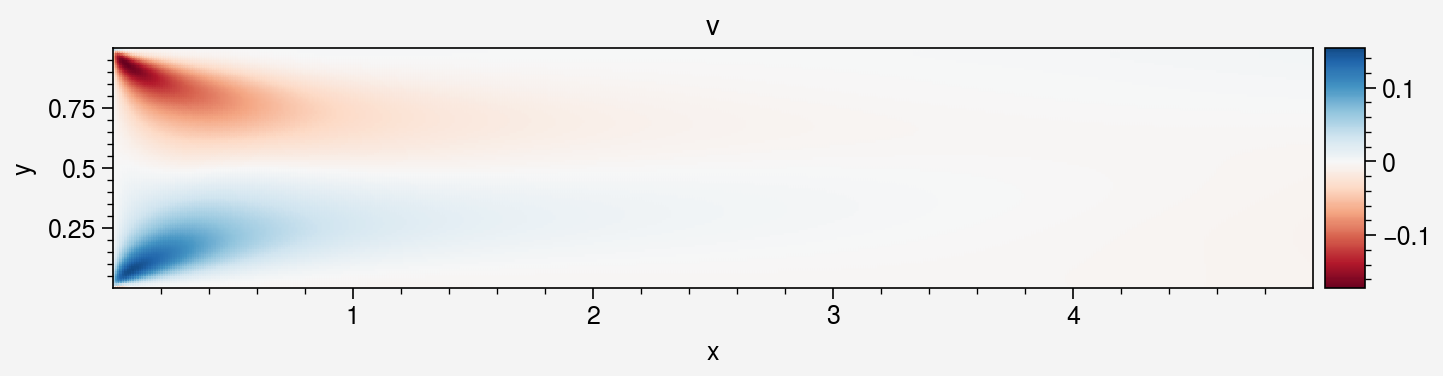

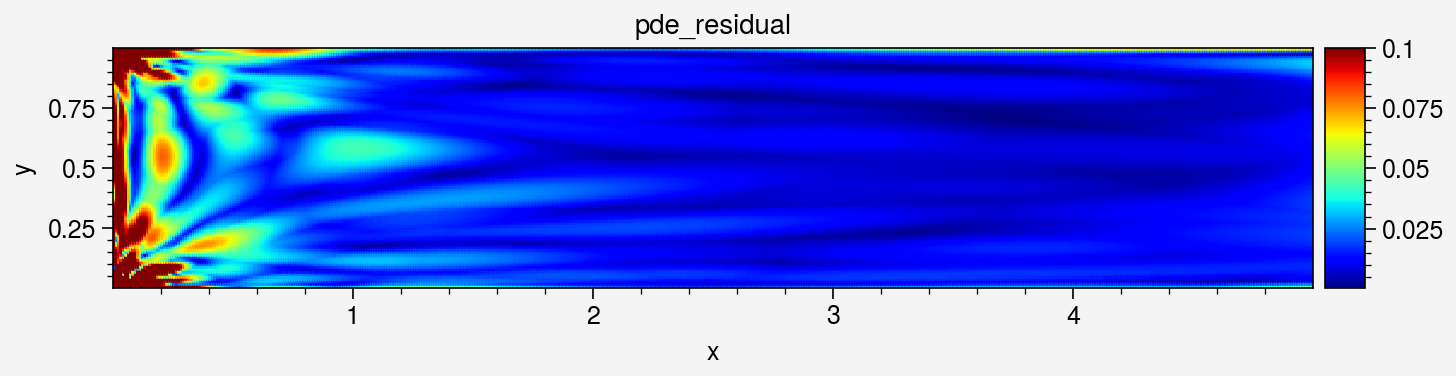

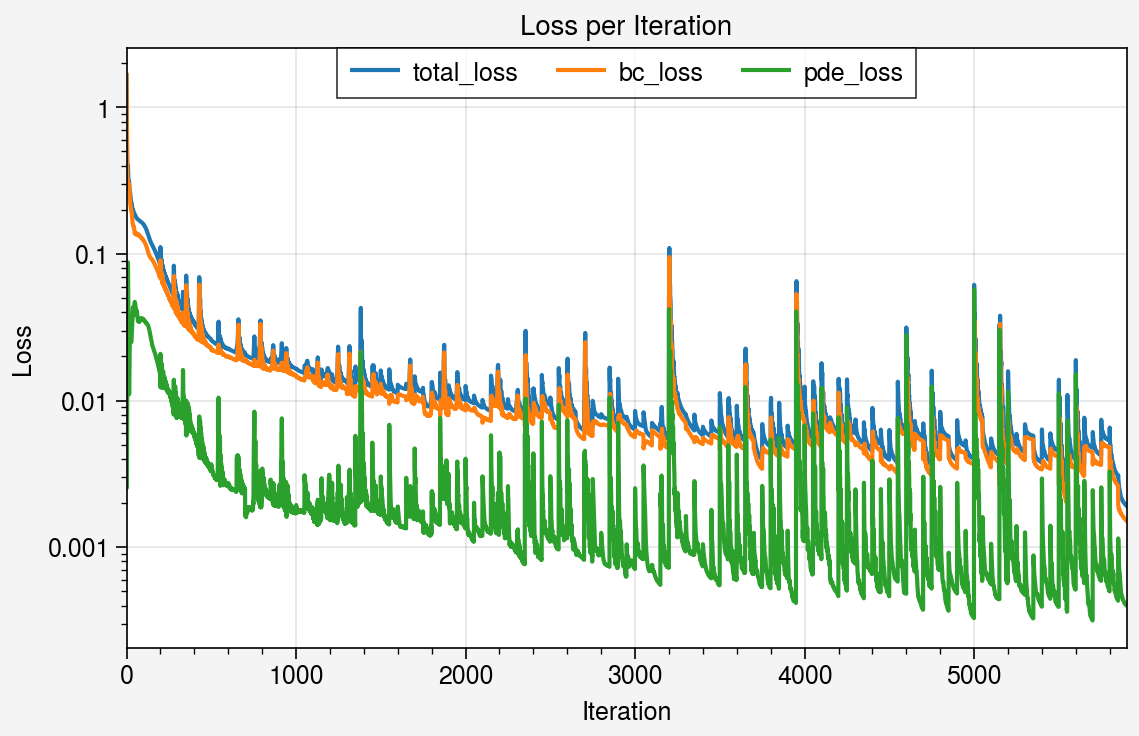

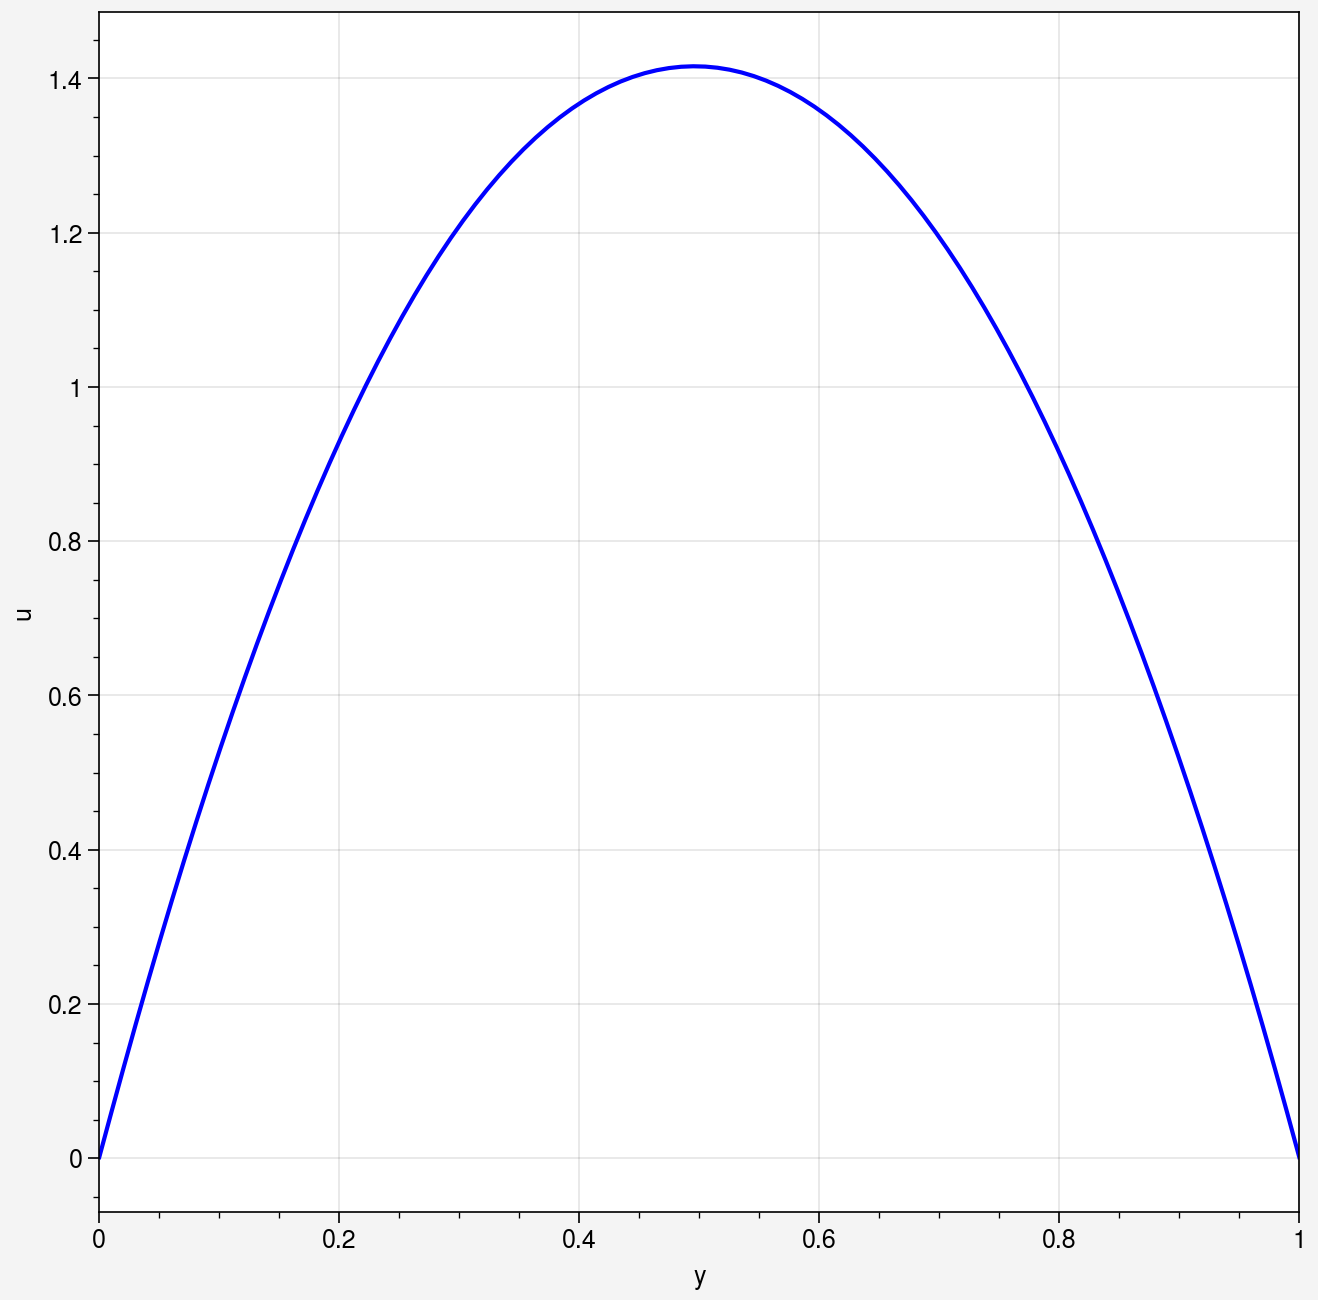

In [ ]:
# Evaluate the best model
prediction = domain.area_list[0].evaluate(model1_best)
prediction.sampling_area([500, 100])

import numpy as np
prediction['u'] = np.clip(prediction['u'],0, 1.5)
prediction['pde_residual'] = np.clip(prediction['pde_residual'],0, 0.1)

# Plot Velocity Field
_ = prediction.plot_color('u', cmap='jet')
_ = prediction.plot_color('v', cmap='RdBu')
# Plot PDE Residual
_ = prediction.plot_color('pde_residual', cmap='jet')
# Plot Training Loss
_ =prediction.plot_loss_curve()

pred = domain.bound_list[2].evaluate(model1_best)
pred.sampling_line(100)
pred.plot(y_axis='u', x_axis='y')